**Materi ini dibuat oleh : [Sardi Irfansyah](https://www.linkedin.com/in/sardi-irfansyah-947bb554/)**


# Dataset Asurasi

Pada topik kali ini, kita akan mencoba memprediksi tagihan asuransi dari dataset berikut:

In [ ]:
# mengambil data
!kaggle datasets download mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
  0% 0.00/16.0k [00:00<?, ?B/s]
100% 16.0k/16.0k [00:00<00:00, 21.6MB/s]


In [ ]:
!unzip -q insurance.zip

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df= pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# cek info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# cek duplikasi data
df.duplicated().sum()

1

In [ ]:
# cek baris yang terduplikasi
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
# drop duplikasi data
df.drop_duplicates(inplace=True)

In [ ]:
# cek kembali duplikasi data
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Penjelasan:
- Sekilas kita bisa mengatahui bahwa `age` distribusi cenderung simetris, ini ditandai dengan nilai mean dan median yang berdekatan.
- Sebagian besar pemilik asuransi berusia sekitar 39 tahun atau berada pada rentang 27-51 tahun.
- Tampak sebagian besar BMI pada dataset tersebut cenderung tidak normal atau obesitas. Hal ini bisa dilihat dari nilai mean atau median.
- Sebagian besar jumlah children berapada pada kisaran 0-2 (cenderung sedikit)

In [ ]:
df['children'].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


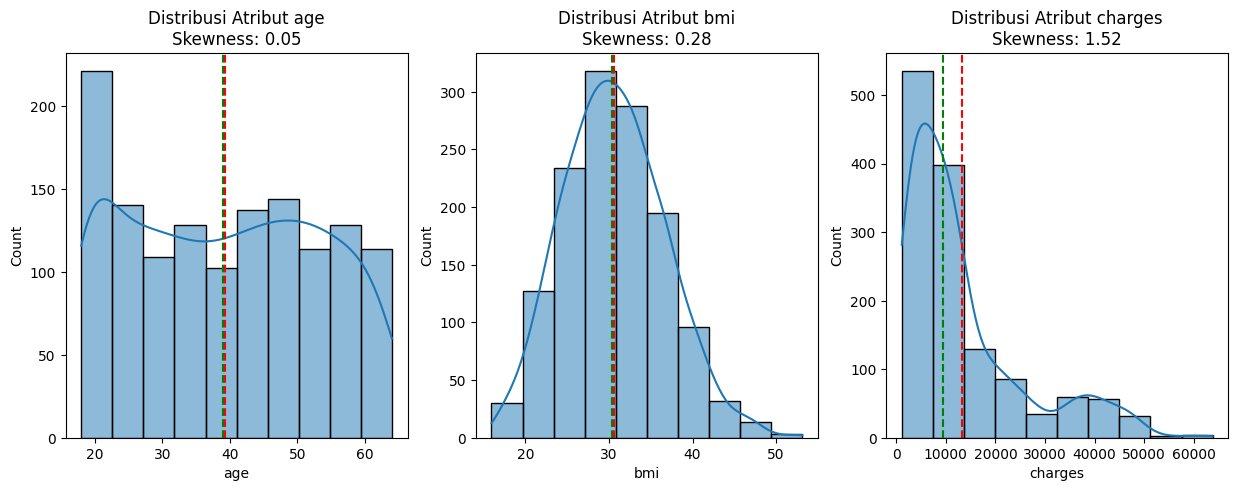

In [ ]:
list_numeric= ['age', 'bmi', 'charges']

fig,ax= plt.subplots(1,3, figsize=(15,5))

for i,col in enumerate(list_numeric):
    sns.histplot(data=df, x=col, ax=ax[i], kde=True, bins=10)
    ax[i].axvline(df[col].mean(), color='r', linestyle='--')
    ax[i].axvline(df[col].median(), color='g', linestyle='--')
    ax[i].set_title(f'Distribusi Atribut {col}\nSkewness: {df[col].skew():.2f}')

Distribusi data BMI cukup simetris dibandingkan dengan data yang lain.

In [ ]:
df['sex'].value_counts(normalize=True)

,proportion
sex,
male,0.504862
female,0.495138


In [ ]:
df['sex'].value_counts(normalize=True)

,proportion
sex,
male,0.504862
female,0.495138


In [ ]:
# cek korelasi antara charges dan age
df[['age','charges']].corr()['charges']

,charges
age,0.298308
charges,1.000000


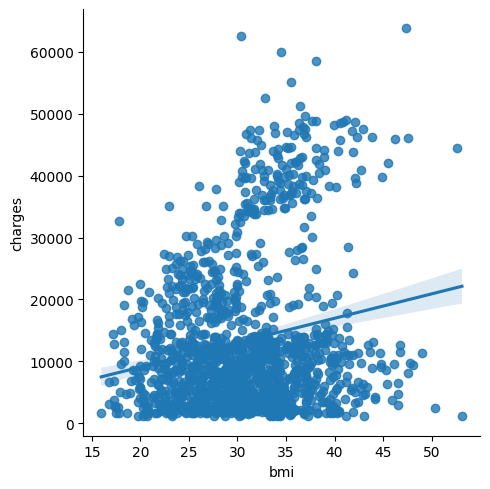

In [ ]:
sns.lmplot(data=df, x='bmi', y='charges');#analisis bivaraite

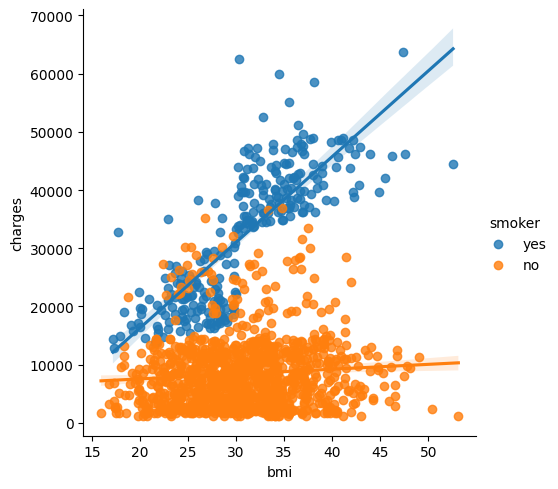

In [ ]:
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker'); #analisis multivariate

**Insight**: Dari gambar tersebut, kita dapat mengetahui bahwa ketika statusnya adalah perokok, biaya asuransi akan cenderung naik seiring dengan naiknya BMI.



In [ ]:
df[['bmi','charges']].corr() #analisis bivariate (membadinkan atua melihat dua variabel)

,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


In [ ]:
#analisis multivariate (membadinkan atua melihat lebih dari dua variabel)
df_smoker_yes= df.query('smoker=="yes"')
df_smoker_yes[['bmi','charges']].corr()

,bmi,charges
bmi,1.000000,0.806481
charges,0.806481,1.000000


In [ ]:
df_smoker_no= df.query('smoker=="no"')
df_smoker_no[['bmi','charges']].corr()

,bmi,charges
bmi,1.000000,0.084077
charges,0.084077,1.000000


## Data Preprocessing

Pada bagian ini kita akan melakukan preprocessing dan juga teknik feature engineering. Agar dapat memahami langkah-langkah dasar dari teknik yang diterapkan maka pada bagian ini kita tidak menggunakan Pipeline terlebih dahulu.

In [ ]:
X= df.drop('charges', axis=1) # menggunakan semua fitur
y= df['charges']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2,
                                                   stratify=X[['smoker','sex','region']],
                                                   random_state=5)

In [ ]:
X_train.shape

(1069, 6)

In [ ]:
X_train.head()

,age,sex,bmi,children,smoker,region
433,60,female,30.50,0,no,southwest
1290,38,female,19.95,2,no,northeast
955,31,male,39.49,1,no,southeast
1292,21,male,23.21,0,no,southeast
1266,55,female,30.50,0,no,southwest


### Encoding

Lakukan Encoding untuk fitur kategorikal

In [ ]:
# Encoding data nominal
# OneHotEncoder
encoder= OneHotEncoder()
encoder.fit(X_train[['sex', 'region']])
X_train_encoded= encoder.transform(X_train[['sex', 'region']])
X_test_encoded= encoder.transform(X_test[['sex', 'region']])

In [ ]:
encoder.get_feature_names_out()

array(['sex_female', 'sex_male', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'], dtype=object)

In [ ]:
# jadikan dalam bentuk dataframe
X_train_encoded_df= pd.DataFrame(X_train_encoded.toarray(), columns=encoder.get_feature_names_out())
X_test_encoded_df= pd.DataFrame(X_test_encoded.toarray(), columns=encoder.get_feature_names_out())

In [ ]:
X_train_encoded_df.head()

,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0


Selanjutnya kita akan coba terapkan ordinal encoder, namun mesti ingat kembali bahwa dibawah ini hanya contoh saja.

In [ ]:
# contoh encoding dengan map atau replace
X_train.replace({'male':0, 'female':1}).head()

,age,sex,bmi,children,smoker,region
433,60,1,30.50,0,no,southwest
1290,38,1,19.95,2,no,northeast
955,31,0,39.49,1,no,southeast
1292,21,0,23.21,0,no,southeast
1266,55,1,30.50,0,no,southwest


In [ ]:
# encoding dengan ordinal untuk smoker,
# Atur urutannya, misalkan: no jadi 0, yes jadi 1
#urutannya sesuai index jadi letakkan tingkat terendah pada index paling awal
ord_smoker= ['no','yes']

encoder_ordinal= OrdinalEncoder(categories=[ ord_smoker])
encoder_ordinal.fit(X_train[['smoker']])
X_train_encoded_ordinal= encoder_ordinal.transform(X_train[['smoker']])
X_test_encoded_ordinal= encoder_ordinal.transform(X_test[['smoker']])

In [ ]:
# jadikan dataframe
X_train_encoded_ordinal_df= pd.DataFrame(X_train_encoded_ordinal, columns=encoder_ordinal.get_feature_names_out())
X_test_encoded_ordinal_df= pd.DataFrame(X_test_encoded_ordinal, columns=encoder_ordinal.get_feature_names_out())

In [ ]:
X_train_encoded_ordinal_df.head()

,smoker
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Scaling

Lakukan Scaling untuk fitur numerikal

In [ ]:
# scaling fitur numerik

scaler= RobustScaler()
scaler.fit(X_train[['age', 'bmi', 'children']])
X_train_scaled= scaler.transform(X_train[['age', 'bmi', 'children']])
X_test_scaled= scaler.transform(X_test[['age', 'bmi', 'children']])

#jadikan dataframe
X_train_scaled_df= pd.DataFrame(X_train_scaled, columns= ['age', 'bmi', 'children'])
X_test_scaled_df= pd.DataFrame(X_test_scaled, columns= ['age', 'bmi', 'children'])

In [ ]:
X_test_scaled_df.head(2)

,age,bmi,children
0,0.307692,-0.716559,-0.5
1,-0.807692,0.760165,-0.5


In [ ]:
#gabungkan dataframe scaling, onehotencoder, dan ordinalencoder
X_train_final= pd.concat([X_train_scaled_df, X_train_encoded_df, X_train_encoded_ordinal_df], axis=1)
X_test_final= pd.concat([X_test_scaled_df, X_test_encoded_df, X_test_encoded_ordinal_df], axis=1)

In [ ]:
X_test_final.head()

,age,bmi,children,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker
0,0.307692,-0.716559,-0.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.807692,0.760165,-0.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.807692,-0.862110,-0.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,0.961538,-0.414260,-0.5,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.076923,0.436064,1.5,0.0,1.0,0.0,0.0,0.0,1.0,1.0


Sekarang fitur kita sudah dalam bentuk numerikal semuanya. Selanjutnya kita akan coba cek korelasi

### Feature Selection

Ingat bahwa seleksi fitur bisa juga dilakukan di awal ketika kita melakukan EDA dan juga bisa berdasarkan domain knowledge terhadap dataset yang kita miliki.

In [ ]:
#lakukan reset index terlebih dahulu agar indexnya sama seperti fitur (X) yaitu dimulai dari 0
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [ ]:
y_train.head(2)

,charges
0,12638.1950
1,7133.9025


Kita akan coba cek korelasi pada keseluruhan fitur dengan beberapa method. Namun perlu diperhatikan bahwa kalian bisa juga mengecek dengan masing-masing metode berikut sesuai dengan kondisi variabelnya, misalkan seperti berikut ini:
- Hubungan fitur numerik dengan target numerik : **pearson** atau **spearman**
- Hubungan fitur kategorik dengan target numerik: **kendall**

In [ ]:
# Hitung korelasi Pearson
pearson_corr = X_train_final.corrwith(y_train, method='pearson')

# Hitung korelasi Kendall
kendall_corr = X_train_final.corrwith(y_train, method='kendall')

# Hitung korelasi spearman
spearman_corr = X_train_final.corrwith(y_train, method='spearman')

# Gabungkan kedua hasil ke dalam satu dataframe
correlation_df = pd.DataFrame({
    'Feature': pearson_corr.index,
    'Pearson': pearson_corr.values,
    'Spearman': spearman_corr.values,
    'Kendall': kendall_corr.values
})

# Reset index agar kolom 'Feature' menjadi bagian dari dataframe
correlation_df.reset_index(drop=True, inplace=True)

# Tampilkan dataframe
display(correlation_df)

,Feature,Pearson,Spearman,Kendall
0,age,0.293296,0.519808,0.465835
1,bmi,0.197064,0.115306,0.080453
2,children,0.061862,0.121683,0.095009
3,sex_female,-0.064221,-0.008052,-0.006577
4,sex_male,0.064221,0.008052,0.006577
5,region_northeast,0.008223,0.048067,0.039265
6,region_northwest,-0.049427,-0.033238,-0.027151
7,region_southeast,0.081228,0.019975,0.016317
8,region_southwest,-0.043055,-0.035423,-0.028937
9,smoker,0.779764,0.659299,0.538567


Untuk seleksi fitur kita bisa atur thresholdnya, misalkan dalam kasus dataset ini kita gunakan threshold 0.1. Jadi jika korelasinya lebih kecil dari 0.1 maka tidak kita gunakan.

In [ ]:
# Membuat dataframe baru dengan nilai absolut
correlation_abs = correlation_df.copy()
correlation_abs[['Pearson', 'Spearman', 'Kendall']] = correlation_abs[['Pearson', 'Spearman', 'Kendall']].abs()

# Menampilkan dataframe baru
correlation_abs

,Feature,Pearson,Spearman,Kendall
0,age,0.293296,0.519808,0.465835
1,bmi,0.197064,0.115306,0.080453
2,children,0.061862,0.121683,0.095009
3,sex_female,0.064221,0.008052,0.006577
4,sex_male,0.064221,0.008052,0.006577
5,region_northeast,0.008223,0.048067,0.039265
6,region_northwest,0.049427,0.033238,0.027151
7,region_southeast,0.081228,0.019975,0.016317
8,region_southwest,0.043055,0.035423,0.028937
9,smoker,0.779764,0.659299,0.538567


Selanjutnya kita akan filter nama fitur yang diatas

In [ ]:
fitur_pearson= correlation_abs[correlation_abs['Pearson']>=0.1]['Feature'].to_list()
fitur_spearman= correlation_abs[correlation_abs['Spearman']>=0.1]['Feature'].to_list()
fitur_kendall= correlation_abs[correlation_abs['Kendall']>=0.1]['Feature'].to_list()

print('seleksi fitur dengan pearson:', fitur_pearson)
print('seleksi fitur dengan spearman:', fitur_spearman)
print('seleksi fitur dengan kendall:', fitur_kendall)

seleksi fitur dengan pearson: ['age', 'bmi', 'smoker']
seleksi fitur dengan spearman: ['age', 'bmi', 'children', 'smoker']
seleksi fitur dengan kendall: ['age', 'smoker']


Dari nilai diatas kita bisa menyimpulkan bahwa fitur `age`,`bmi`, `children` dan `smoker` memiliki korelasi dengan `charges`. Ini juga bisa dibuktikan dari hasil EDA yang sebelumnya telah kita lakukan.

Selain teknik diatas kita juga bisa gunakan teknik lain seperti **ANOVA**, **SHAP** (SHapley Additive exPlanations), **RFE**
 (Recursive Feature Elimination), dan masih banyak lagi.

## Model Development

Pada bagian ini kita akan coba membandikan hasil penerapan feature engineering terhadap performa model linear regression.

### Linear Regression Tanpa Seleksi Fitur

In [ ]:
%%time
linreg_1= LinearRegression()
linreg_1.fit(X_train_final, y_train)

CPU times: user 6.23 ms, sys: 12 µs, total: 6.25 ms
Wall time: 20.9 ms


LinearRegression()

#### Evaluasi Model Tanpa Cross Validation

In [ ]:
y_pred_train= linreg_1.predict(X_train_final)
y_pred_test= linreg_1.predict(X_test_final)


mae_train = round(mean_absolute_error(y_train, y_pred_train), 3)
r2_train = round(r2_score(y_train, y_pred_train), 3)
mse_train = round(mean_squared_error(y_train, y_pred_train), 3)
rmse_train = round(np.sqrt(mse_train), 3)

mae_test = round(mean_absolute_error(y_test, y_pred_test), 3)
r2_test = round(r2_score(y_test, y_pred_test), 3)
mse_test = round(mean_squared_error(y_test, y_pred_test), 3)
rmse_test = round(np.sqrt(mse_test), 3)


print('Hasil Evaluasi Menggunakan Semua Fitur')
print('Hasil Train:')
print('MAE:', mae_train)
print('MSE:', mse_train)
print('RMSE:',rmse_train)
print('R2 score:', r2_train)


print('\nHasil Test:')
print('MAE:', mae_test)
print('MSE:', mse_test)
print('RMSE:',rmse_test)
print('R2 score:', r2_test)

Hasil Evaluasi Menggunakan Semua Fitur
Hasil Train:
MAE: 4275.825
MSE: 37705905.725
RMSE: 6140.513
R2 score: 0.741

Hasil Test:
MAE: 3901.998
MSE: 31983621.64
RMSE: 5655.406
R2 score: 0.787


Jika kita tidak menggunakan cross validation, maka skor diatas mungkin tidak akurat, karena bisa saja ketika sample yang kita gunakan berbeda atau keacakannya beda maka hasil evaluasinya akan berbeda pula.

Misalkan kalian bisa coba ubah nilai `random_state` pada `train_test_split`. Ketika kalian ubah nilai tersebut maka hasil dari evaluasinya akan berbeda.

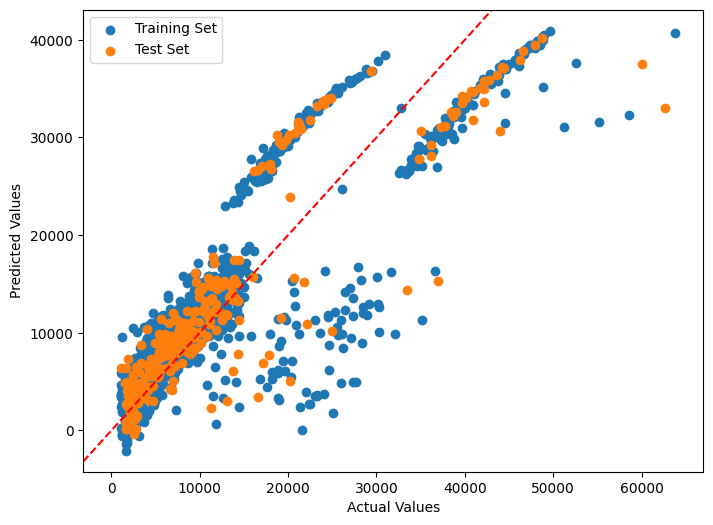

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, label='Training Set')
plt.scatter(y_test, y_pred_test, label='Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.axline((0, 0), slope=1, color='red', linestyle='--')  # Line y = x
plt.legend()
plt.show()

**Catatan**: Dalam skenario yang ideal, dimana nilai prediksi benar-benar cocok dengan nilai aktual, semua titik akan jatuh di sepanjang garis diagonal (y = x).

#### Evaluasi Model dengan Cross Validation

Pada bagian ini kita akan coba evaluasi model yang dengan cross validation menggunakan fungsi `cross_validate` yang ada pada `sklearn.model_selection`. Metode ini berbeda dengan `train_test_split` yang sebelumnya telah kita gunakan.

In [ ]:
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate

In [ ]:
#misalkan kita kembalikan jumlah data seperti sebelum train_test_split
X_full_data= pd.concat([X_train_final, X_test_final], axis=0)
y_full_data= pd.concat([y_train, y_test], axis=0)

Selain gunakan X_full_data, kita bisa juga menggunakan X_train_final langsung sebagai data yang nantinya akan split menjadi train dan test (validation). Dengan Asumsi kita ingin melakukan validasi terlebih dahulu sebelum testing.

In [ ]:
# Inisialisasi model
model_1 = LinearRegression()

# Mendefinisikan scorer untuk MAE, MSE, dan RMSE
mae_scorer = make_scorer(mean_absolute_error)
mse_scorer = make_scorer(mean_squared_error)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

# Cross-validation dengan beberapa metrik evaluasi
cv_results = cross_validate(model_1, X_full_data, y_full_data,
                            cv=5,
                            scoring={'r2': 'r2', 'mae': mae_scorer, 'mse': mse_scorer, 'rmse': rmse_scorer},
                            return_train_score=True)

# Menampilkan hasil cross-validation
print(f"Rata-rata Train R2: {np.mean(cv_results['train_r2']):.3f}")
print(f"Rata-rata Test R2: {np.mean(cv_results['test_r2']):.3f}")
print(f"Rata-rata Train MAE: {np.mean(cv_results['train_mae']):.3f}")
print(f"Rata-rata Test MAE: {np.mean(cv_results['test_mae']):.3f}")
print(f"Rata-rata Train MSE: {np.mean(cv_results['train_mse']):.3f}")
print(f"Rata-rata Test MSE: {np.mean(cv_results['test_mse']):.3f}")
print(f"Rata-rata Train RMSE: {np.mean(cv_results['train_rmse']):.3f}")
print(f"Rata-rata Test RMSE: {np.mean(cv_results['test_rmse']):.3f}")

Rata-rata Train R2: 0.751
Rata-rata Test R2: 0.747
Rata-rata Train MAE: 4172.776
Rata-rata Test MAE: 4197.716
Rata-rata Train MSE: 36484156.906
Rata-rata Test MSE: 36930236.134
Rata-rata Train RMSE: 6039.344
Rata-rata Test RMSE: 6064.327


Rata-rata diatas adalah hasil dari cross validation yang mana kita mencoba melakukan split data dengan sample yang berbeda-beda agar evaluasi model kita lebih akurat.

### Linear Regression dengan Seleksi Fitur

In [ ]:
list_fitur= ['age', 'bmi', 'children', 'smoker'] #fitur yang dipilih
X_train_fs= X_train_final[list_fitur]
X_test_fs= X_test_final[list_fitur]

In [ ]:
%%time
linreg_2= LinearRegression()
linreg_2.fit(X_train_fs, y_train)

CPU times: user 4.81 ms, sys: 0 ns, total: 4.81 ms
Wall time: 4.91 ms


LinearRegression()

In [ ]:
y_pred_train= linreg_2.predict(X_train_fs)
y_pred_test= linreg_2.predict(X_test_fs)


mae_train = round(mean_absolute_error(y_train, y_pred_train), 3)
r2_train = round(r2_score(y_train, y_pred_train), 3)
mse_train = round(mean_squared_error(y_train, y_pred_train), 3)
rmse_train = round(np.sqrt(mse_train), 3)

mae_test = round(mean_absolute_error(y_test, y_pred_test), 3)
r2_test = round(r2_score(y_test, y_pred_test), 3)
mse_test = round(mean_squared_error(y_test, y_pred_test), 3)
rmse_test = round(np.sqrt(mse_test), 3)


print('Hasil Evaluasi Menggunakan Semua Fitur')
print('Hasil Train:')
print('MAE:', mae_train)
print('MSE:', mse_train)
print('RMSE:',rmse_train)
print('R2 score:', r2_train)


print('\nHasil Test:')
print('MAE:', mae_test)
print('MSE:', mse_test)
print('RMSE:',rmse_test)
print('R2 score:', r2_test)

Hasil Evaluasi Menggunakan Semua Fitur
Hasil Train:
MAE: 4275.513
MSE: 37880928.197
RMSE: 6154.748
R2 score: 0.74

Hasil Test:
MAE: 3918.898
MSE: 32094209.512
RMSE: 5665.175
R2 score: 0.786


Selanjutnya kita coba gunakan cross validation

In [ ]:
X_full_data= pd.concat([X_train_fs, X_test_fs], axis=0)
y_full_data= pd.concat([y_train, y_test], axis=0)

In [ ]:
# Inisialisasi model
model_2 = LinearRegression()

# Mendefinisikan scorer untuk MAE, MSE, dan RMSE
mae_scorer = make_scorer(mean_absolute_error)
mse_scorer = make_scorer(mean_squared_error)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

# Cross-validation dengan beberapa metrik evaluasi
cv_results = cross_validate(model_2, X_full_data, y_full_data,
                            cv=5,
                            scoring={'r2': 'r2', 'mae': mae_scorer, 'mse': mse_scorer, 'rmse': rmse_scorer},
                            return_train_score=True)

# Menampilkan hasil cross-validation
print(f"Rata-rata Train R2: {np.mean(cv_results['train_r2']):.3f}")
print(f"Rata-rata Test R2: {np.mean(cv_results['test_r2']):.3f}")
print(f"Rata-rata Train MAE: {np.mean(cv_results['train_mae']):.3f}")
print(f"Rata-rata Test MAE: {np.mean(cv_results['test_mae']):.3f}")
print(f"Rata-rata Train MSE: {np.mean(cv_results['train_mse']):.3f}")
print(f"Rata-rata Test MSE: {np.mean(cv_results['test_mse']):.3f}")
print(f"Rata-rata Train RMSE: {np.mean(cv_results['train_rmse']):.3f}")
print(f"Rata-rata Test RMSE: {np.mean(cv_results['test_rmse']):.3f}")

Rata-rata Train R2: 0.750
Rata-rata Test R2: 0.747
Rata-rata Train MAE: 4180.770
Rata-rata Test MAE: 4189.164
Rata-rata Train MSE: 36687994.396
Rata-rata Test MSE: 36885260.575
Rata-rata Train RMSE: 6056.213
Rata-rata Test RMSE: 6060.638


Kita dapat melihat bahwa hasil evaluasi model setelah seleksi fitur tampaknya memiliki error yang tidak berbeda signifikan dengan menggunakan seluruh fitur. Dari sisi waktu pelatihan kita juga telah menghemat jumlah komputasi.

Untuk mendapatkan performa yang lebih baik dan evaluasi yang lebih akurat, anda mungkin dapat lakukan beberapa hal berikut:
- Ubah teknik Scaling yang digunakan, misal dengan MinMaxScaler atau StandardScaler. (catatan: Biasanya pengubahan teknik scaling tidak signifikan efek perubahannya, namun patut jadi pertimbangan)
- Lakukanlah penanganan Outlier
- Jika tetap ingin menggunakan regresi linear, coba terapkan regularisasi (Ridge atau Lasso Regression)


## Pipeline

**Pipeline** dalam konteks machine learning adalah sebuah objek atau alur kerja yang menggabungkan berbagai langkah preprocessing, transformasi, dan pemodelan dalam satu kesatuan yang terstruktur. Tujuan utama dari pipeline adalah untuk mengotomatisasi proses dan membuat alur kerja model menjadi lebih bersih dan lebih mudah dipahami, serta memungkinkan pengujian dan penerapan model secara lebih efisien.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from scipy.stats import spearmanr


# Menentukan kolom numerik dan kategorikal
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'region', 'smoker']

# Imputasi untuk fitur numerik dan kategorikal
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Mengimputasi dengan median untuk data numerik
    ('scaler', RobustScaler())  # Scaling numerik dengan RobustScaler
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Mengimputasi dengan modus untuk data kategorikal
    ('encoder', OneHotEncoder(handle_unknown='ignore',drop='first'))  # OneHotEncoding untuk data kategorikal
])

# Menggunakan ColumnTransformer untuk preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),  # Transformasi numerik
        ('cat', categorical_transformer, categorical_features)  # Transformasi kategorikal
    ],
    remainder='passthrough'  # Menjaga fitur yang tidak dikenali tetap ada
)

Sebelum kita gabungkan dengan pipeline model, kita bisa mencoba mengecek terlebih dahulu hasil dari trasformasi yang dilakukan.

In [ ]:
# Melakukan preprocessing pada data training dan test
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [ ]:
num_cols= preprocessor.transformers_[0][1].named_steps['scaler'].get_feature_names_out(numerical_features).tolist()
num_cols

['age', 'bmi', 'children']

In [ ]:
cat_cols= preprocessor.transformers_[1][1].named_steps['encoder'].get_feature_names_out(categorical_features).tolist()
cat_cols

['sex_male',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'smoker_yes']

Ingat bahwa di pipeline yang kita buat sebelumnya kita menggunakan `drop='first'` pada OneHotEncoder, sehingga jumlah kolom yang digunakan lebih sedikit dibandingkan tanpa kita drop.

In [ ]:
# Mendapatkan nama kolom hasil encoding dan scaling
# Untuk fitur numerik, kita akan mendapatkan nama kolom dari scaler
encoded_columns = (num_cols + cat_cols)

# Mengonversi hasil preprocessing ke DataFrame untuk mempermudah analisis
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, columns=encoded_columns)
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, columns=encoded_columns)

In [ ]:
print(X_train_preprocessed_df.shape)
print(X_test_preprocessed_df.shape)

(1069, 8)
(268, 8)


In [ ]:
X_train_preprocessed_df.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
0,0.807692,0.011786,-0.5,0.0,0.0,0.0,1.0,0.0
1,-0.038462,-1.231585,0.5,0.0,0.0,0.0,0.0,0.0
2,-0.307692,1.071302,0.0,1.0,0.0,1.0,0.0,0.0
3,-0.692308,-0.847378,-0.5,1.0,0.0,1.0,0.0,0.0
4,0.615385,0.011786,-0.5,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Fungsi untuk mendapatkan skor Spearman dari data
def spearman_score(X, y):
    return spearmanr(X, y)[0]  # Mengambil hanya koefisien korelasi Spearman

In [ ]:
# Terapkan fungsi spearman_score untuk setiap kolom pada X_train
spearman_scores = X_train_preprocessed_df.apply(lambda col: spearman_score(col, y_train))

# Menampilkan hasil korelasi Spearman
print(spearman_scores)

age                 0.519808
bmi                 0.115306
children            0.121683
sex_male            0.008052
region_northwest   -0.033238
region_southeast    0.019975
region_southwest   -0.035423
smoker_yes          0.659299
dtype: float64


kita juga bisa gunakan `mutual_info_regression` untuk melakukan seleksi fitur.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

# Menghitung Mutual Information untuk setiap fitur
mutual_info = mutual_info_regression(X_train_preprocessed, y_train)

# Membuat DataFrame untuk melihat hasilnya
mutual_info_df = pd.DataFrame(mutual_info, index=X_train_preprocessed_df.columns, columns=['Mutual Information'])

# Memilih fitur dengan nilai mutual information tertinggi
# Misalnya memilih 5 fitur teratas
top_features = mutual_info_df.nlargest(5, 'Mutual Information')
print(f"Top 5 features based on Mutual Information:\n{top_features}")


Top 5 features based on Mutual Information:
            Mutual Information
age                   1.417593
smoker_yes            0.369956
sex_male              0.147642
children              0.141507
bmi                   0.089987


Selanjutnya kita gabungkan Preprocessor dengan model ke dalam satu pipeline.

In [ ]:
# Pipeline lengkap
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(mutual_info_regression, k=5)),  # Memilih 5 fitur terbaik berdasarkan Mutual Information
    ('model', LinearRegression())  # Model Linear Regression
])

In [ ]:
# Melatih pipeline dengan data training
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'region',
                                                   'smoker'])])),
                ('feature_selection',
                 SelectKBest(k=5,
                             score_func=<function mutual_info_regression at 0x7bdbbaea89d0>)),
                ('model', LinearRegression())])

In [ ]:
# Prediksi pada data train dan test
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Hitung MAE, RMSE, dan R² untuk data train
mae_train = round(mean_absolute_error(y_train, y_pred_train), 3)
rmse_train = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 3)
r2_train = round(r2_score(y_train, y_pred_train), 3)

# Hitung MAE, RMSE, dan R² untuk data test
mae_test = round(mean_absolute_error(y_test, y_pred_test), 3)
rmse_test = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 3)
r2_test = round(r2_score(y_test, y_pred_test), 3)

# Menampilkan hasil evaluasi
print("Hasil Evaluasi untuk Data Train:")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R²:", r2_train)

print("\nHasil Evaluasi untuk Data Test:")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R²:", r2_test)

Hasil Evaluasi untuk Data Train:
MAE: 4275.26
RMSE: 6154.719
R²: 0.74

Hasil Evaluasi untuk Data Test:
MAE: 3920.573
RMSE: 5666.537
R²: 0.786


In [ ]:
# Mendefinisikan fungsi scorer untuk MAE, RMSE, dan R²
scorers = {
    'mae': make_scorer(mean_absolute_error),
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'r2': make_scorer(r2_score)
}


# Melakukan cross-validation
cv_results = cross_validate(pipeline, X_train, y_train, cv=5, scoring=scorers, return_train_score=False)

# Menampilkan hasil evaluasi
print("Evaluasi Model menggunakan Cross-Validation:")
print("Rata-rata MAE:", round(np.mean(cv_results['test_mae']), 3))
print("Rata-rata RMSE:", round(np.mean(cv_results['test_rmse']), 3))
print("Rata-rata R²:", round(np.mean(cv_results['test_r2']), 3))

Evaluasi Model menggunakan Cross-Validation:
Rata-rata MAE: 4299.556
Rata-rata RMSE: 6180.174
Rata-rata R²: 0.734


## Save Model

kita bisa coba simpan model yang telah dibuat untuk digunakan kembali dan memprediksi data baru.

In [ ]:
#save model
import joblib
joblib.dump(pipeline, 'model_pipeline.pkl')

['model_pipeline.pkl']

## Model Inference

Sekarang kita bisa coba load model yang telah dibuat dan prediksi ke data baru.

In [ ]:
# load model
pipeline = joblib.load('model_pipeline.pkl')

In [ ]:
# buat sample data_baru dictionary untuk inference
data_baru = {
    'age': 30,
    'sex': 'male',
    'bmi': 25,
    'children': 2,
    'smoker': 'no',
    'region': 'southeast'
}

# Convert the dictionary to a DataFrame
import pandas as pd
new_data_df = pd.DataFrame([data_baru])

# Perform inference using the loaded pipeline
predictions = pipeline.predict(new_data_df)

# Print the predictions
predictions

array([4816.04684373])